In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter1d

DATA  = "../data/attention_over_time_seed1.npz"
SIGMA = 50
MAX_TIMESTEPS = 10000

TOKEN_NAMES  = ["torso", "hip_1", "hip_2", "hip_3", "hip_4",
                "ankle_1", "ankle_2", "ankle_3", "ankle_4"]
LAYER_STYLES = ["-", "--"]  # solid = layer 0, dashed = layer 1

In [3]:
d = np.load(DATA)
actor_attn   = d["actor_attn"]    # [T, n_layers, n_heads, 9, 9]
critic_attn  = d["critic_attn"]   # [T, n_layers, n_heads, 9, 9]
rewards      = d["rewards"]        # [T]
episode_ends = d["episode_ends"]   # [E] — cumulative step indices

# average over heads → [T, n_layers, 9, 9]
attn_by_layer   = actor_attn.mean(axis=2)
critic_by_layer = critic_attn.mean(axis=2)
n_layers = attn_by_layer.shape[1]
T = actor_attn.shape[0]
print(f"steps={T}  episodes={len(episode_ends)}  layers={n_layers}")

steps=94463  episodes=100  layers=2


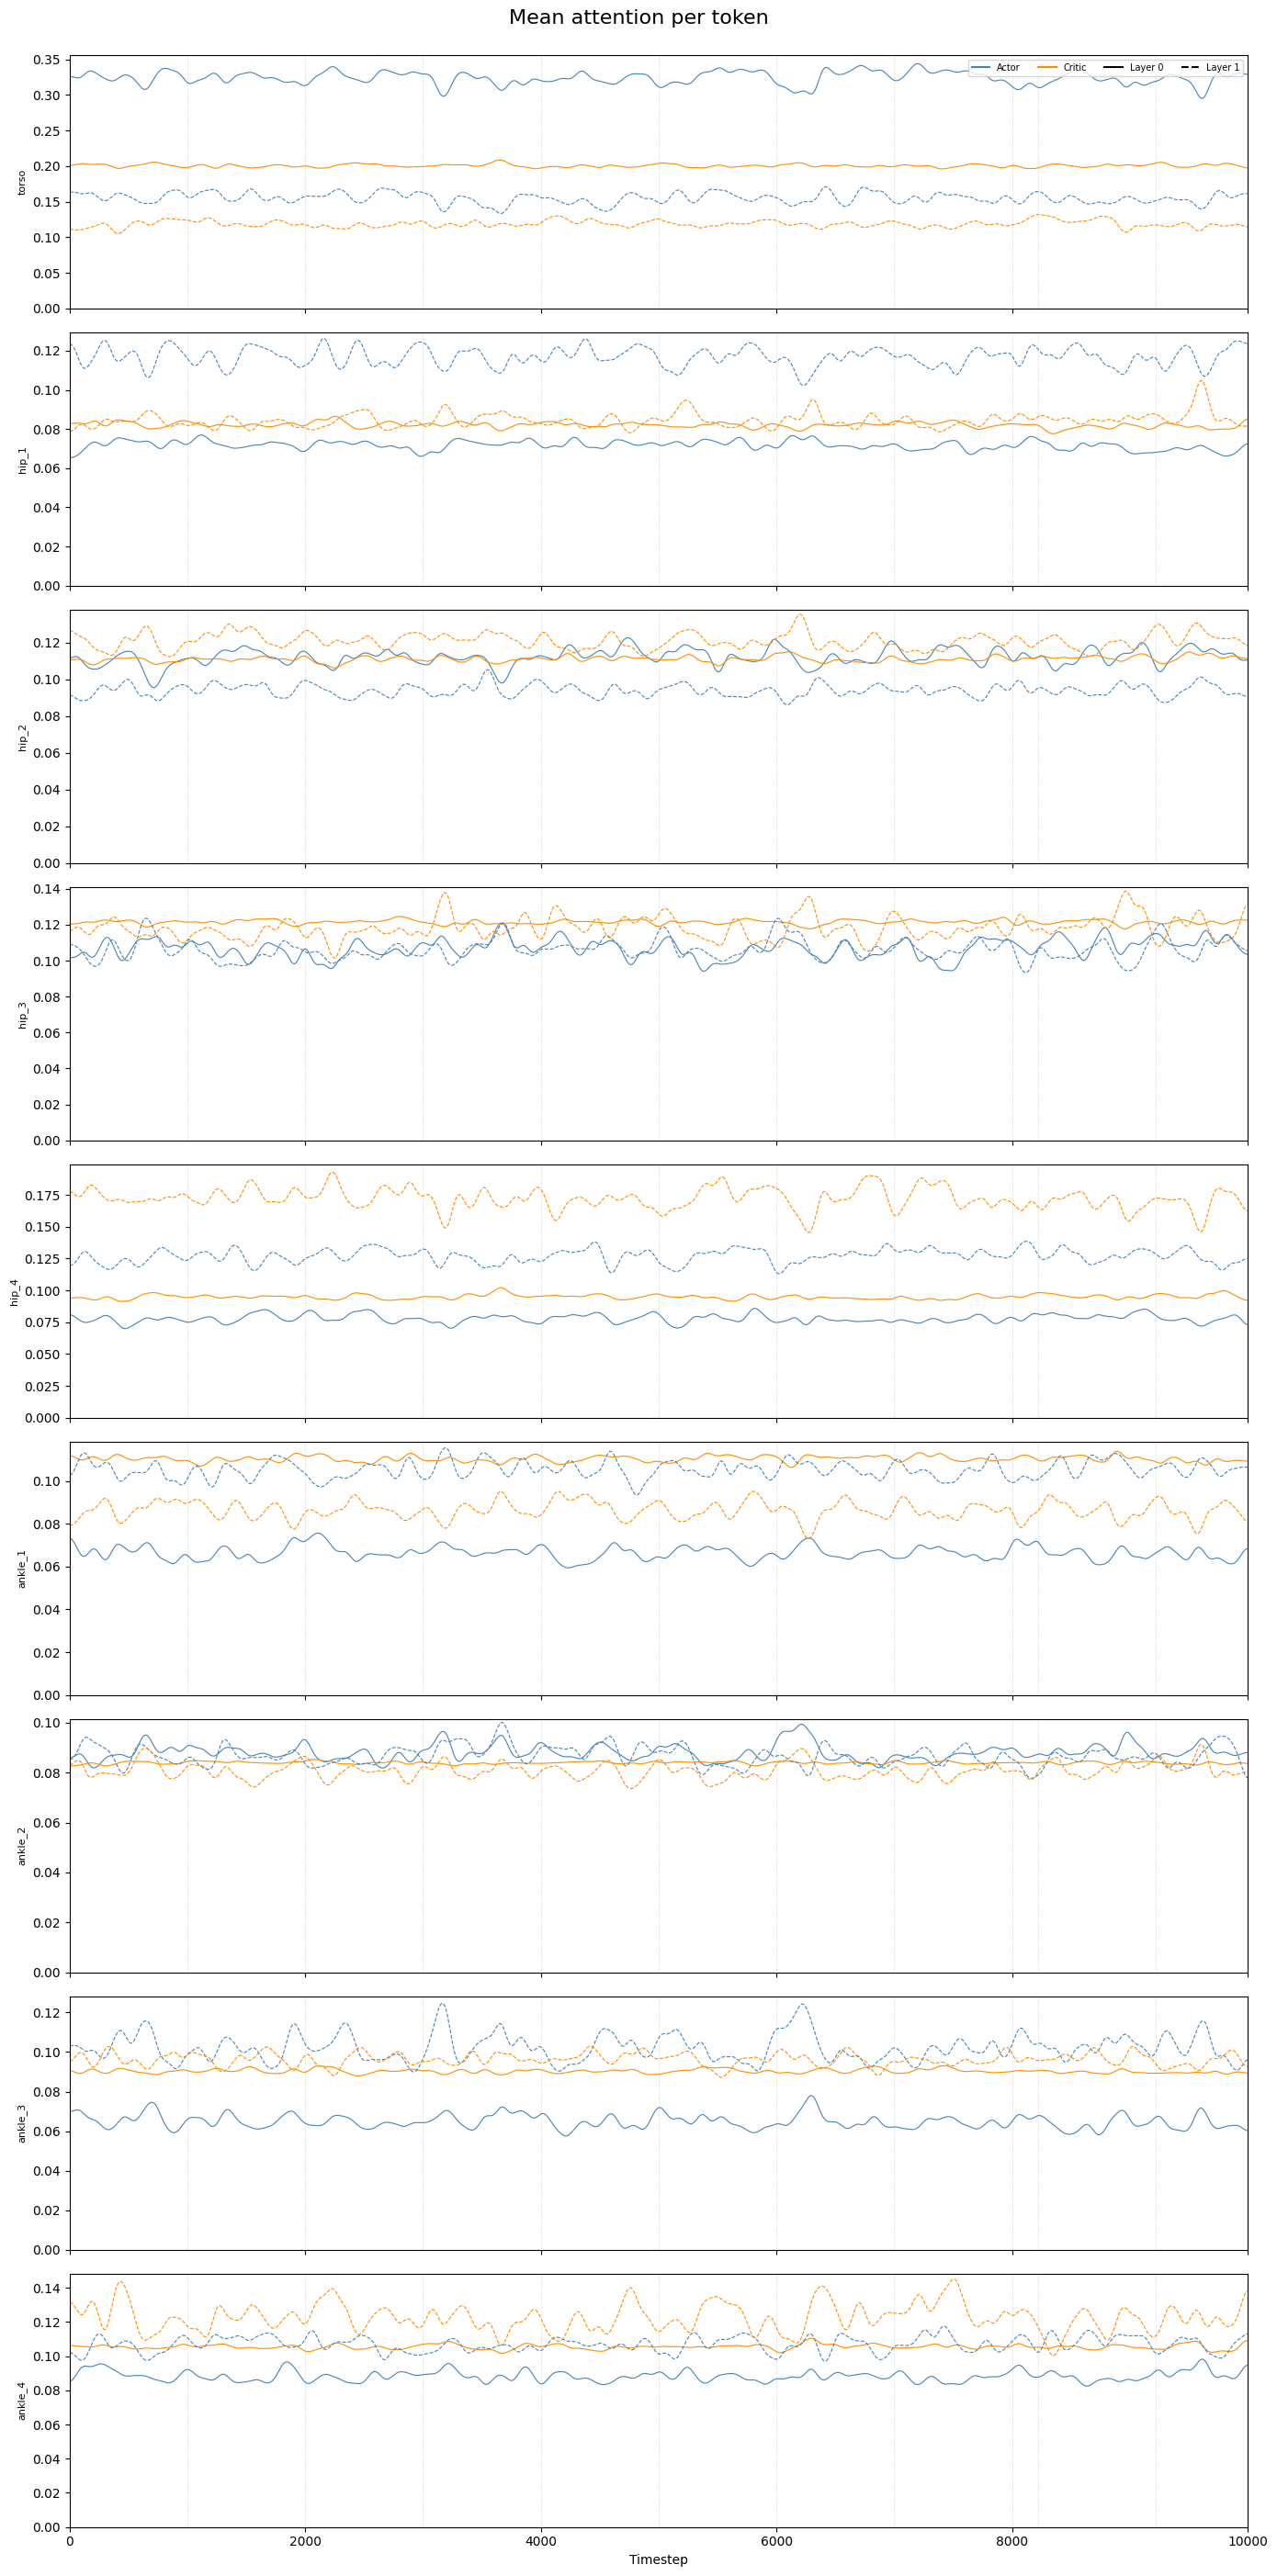

In [4]:
ACTOR_COLOR  = "steelblue"
CRITIC_COLOR = "darkorange"

fig, axes = plt.subplots(9, 1, figsize=(14, 28), sharex=True)

for j, ax in enumerate(axes):
    for layer in range(n_layers):
        ls = LAYER_STYLES[layer]
        for data, color, name in [
            (attn_by_layer,   ACTOR_COLOR,  "actor"),
            (critic_by_layer, CRITIC_COLOR, "critic"),
        ]:
            series   = data[:MAX_TIMESTEPS, layer, :, j].mean(axis=1).astype(float)
            smoothed = gaussian_filter1d(series, sigma=SIGMA)
            ax.plot(smoothed, color=color, linestyle=ls, linewidth=0.8,
                    label=f"{name} L{layer}" if j == 0 else "_")
    for end in episode_ends[:-1]:
        ax.axvline(end, color="gray", linestyle=":", linewidth=0.5, alpha=0.5)
    ax.set_ylabel(TOKEN_NAMES[j], fontsize=8)
    ax.set_ylim(0, None)
    ax.set_xlim(0, MAX_TIMESTEPS)

actor_h  = Line2D([0],[0], color=ACTOR_COLOR,  label="Actor")
critic_h = Line2D([0],[0], color=CRITIC_COLOR, label="Critic")
l0_h = Line2D([0],[0], color="k", linestyle="-",  label="Layer 0")
l1_h = Line2D([0],[0], color="k", linestyle="--", label="Layer 1")
axes[0].legend(handles=[actor_h, critic_h, l0_h, l1_h], ncol=4, fontsize=7, loc="upper right")

axes[-1].set_xlabel("Timestep")
fig.suptitle(f"Mean attention per token", fontsize=16, y=1)
plt.tight_layout()
plt.savefig("../data/attention_over_time.png", dpi=150)
plt.show()

In [5]:
ep_starts = np.concatenate([[0], episode_ends[:-1]])

def episode_received(attn_4d):
    """attn_4d [T, layers, 9, 9] -> [E, layers, 9]: mean attention received per token per episode per layer."""
    return np.array([
        attn_4d[s:e].mean(axis=(0, 2))  # mean over time & src -> [layers, 9]
        for s, e in zip(ep_starts, episode_ends)
    ])

actor_ep  = episode_received(attn_by_layer)   # [E, n_layers, 9]
critic_ep = episode_received(critic_by_layer) # [E, n_layers, 9]
print(f"actor_ep={actor_ep.shape}  critic_ep={critic_ep.shape}")

actor_ep=(100, 2, 9)  critic_ep=(100, 2, 9)


/tmp/ipykernel_1352146/238112274.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data[:, layer, j] for j in range(9)], labels=TOKEN_NAMES, patch_artist=True,
/tmp/ipykernel_1352146/238112274.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data[:, layer, j] for j in range(9)], labels=TOKEN_NAMES, patch_artist=True,
/tmp/ipykernel_1352146/238112274.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data[:, layer, j] for j in range(9)], labels=TOKEN_NAMES, patch_artist=True,
/tmp/ipykernel_1352146/238112274.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot(

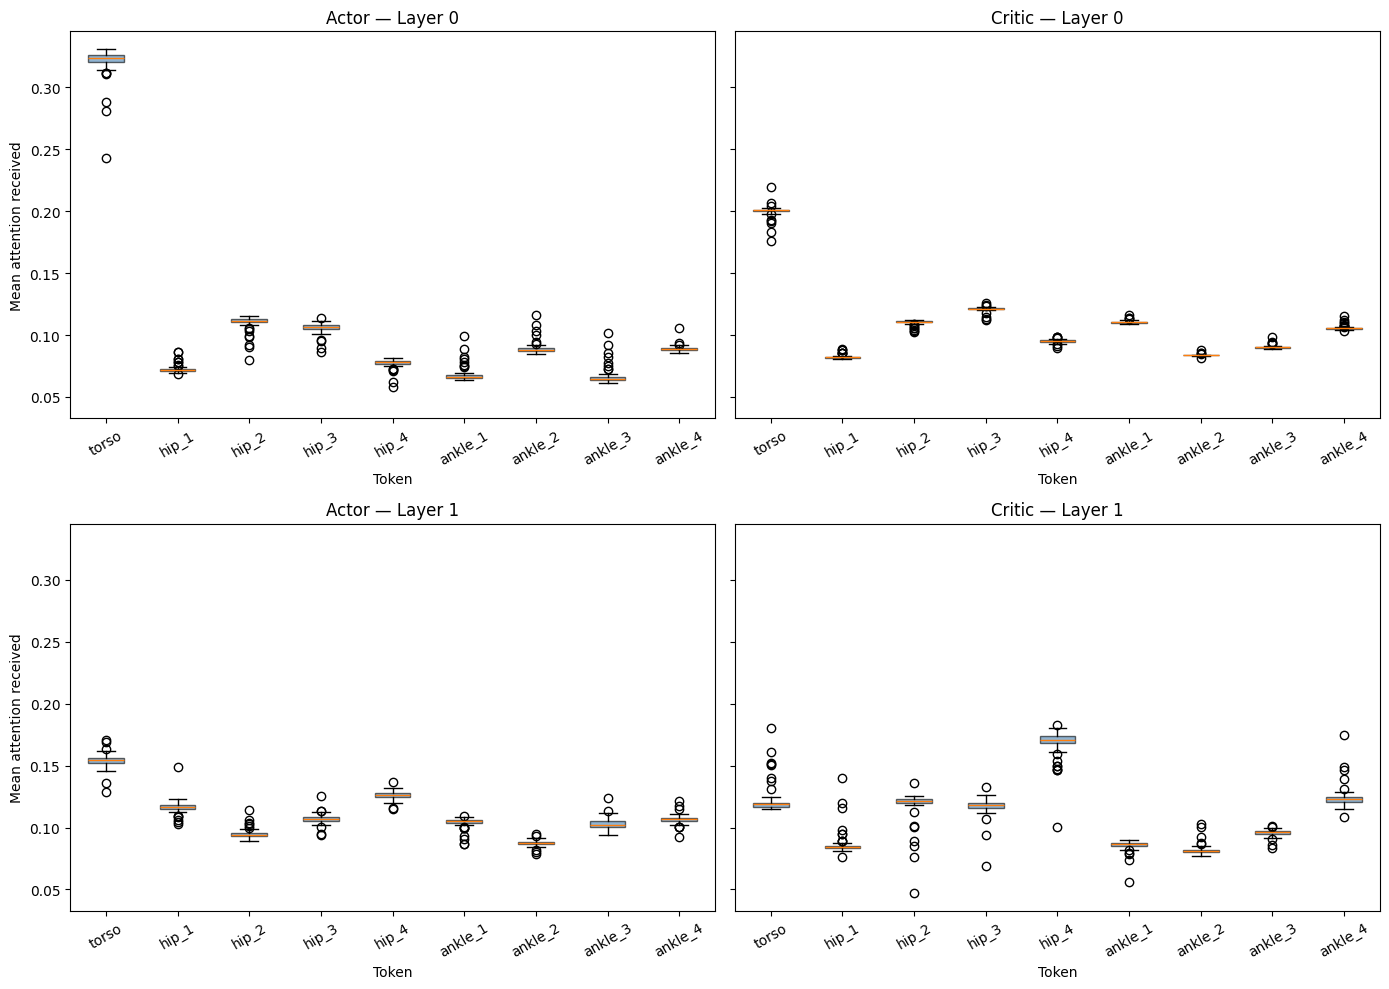

In [6]:
fig, axes = plt.subplots(n_layers, 2, figsize=(14, 5 * n_layers), sharey=True)

for row, layer in enumerate(range(n_layers)):
    for col, (data, title) in enumerate([(actor_ep, "Actor"), (critic_ep, "Critic")]):
        ax = axes[row, col]
        ax.boxplot([data[:, layer, j] for j in range(9)], labels=TOKEN_NAMES, patch_artist=True,
                   boxprops=dict(facecolor="steelblue", alpha=0.6))
        ax.set_title(f"{title} — Layer {layer}")
        ax.set_xlabel("Token")
        ax.tick_params(axis="x", rotation=30)
        if col == 0:
            ax.set_ylabel("Mean attention received")

plt.tight_layout()
plt.savefig("../data/attention_boxplot.png", dpi=150)
plt.show()

/tmp/ipykernel_1352146/3386376941.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data[:, layer, g] for g in range(len(GROUP_NAMES))],
/tmp/ipykernel_1352146/3386376941.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data[:, layer, g] for g in range(len(GROUP_NAMES))],
/tmp/ipykernel_1352146/3386376941.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data[:, layer, g] for g in range(len(GROUP_NAMES))],
/tmp/ipykernel_1352146/3386376941.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support f

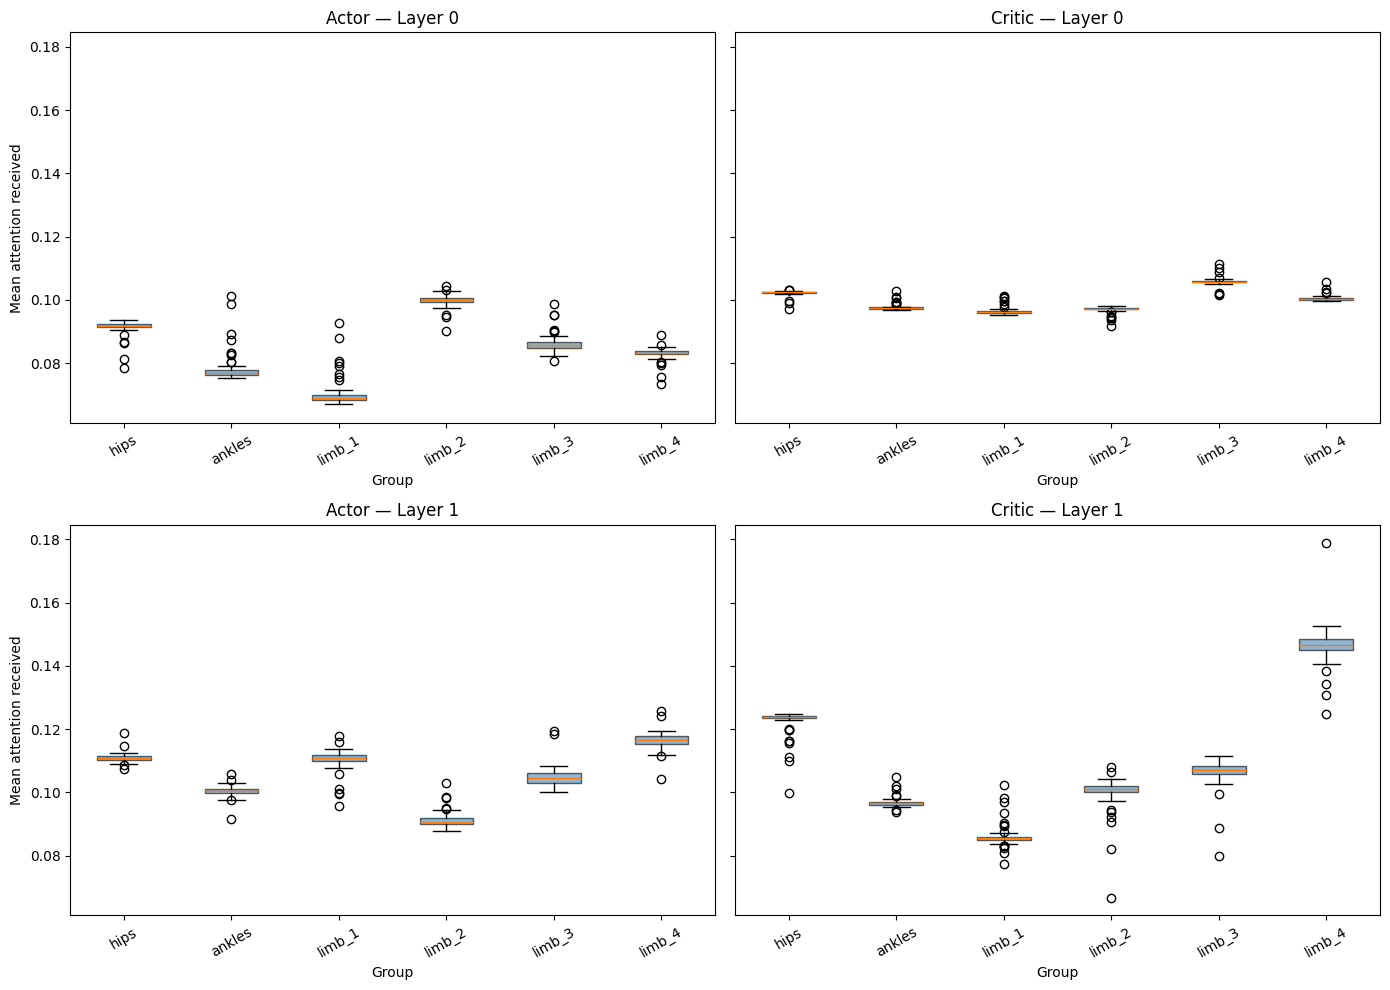

In [7]:
GROUP_NAMES = ["hips", "ankles", "limb_1", "limb_2", "limb_3", "limb_4"]
GROUP_INDICES = [
    [1, 2, 3, 4],   # hips
    [5, 6, 7, 8],   # ankles
    [1, 5],          # limb_1: hip_1 + ankle_1
    [2, 6],          # limb_2
    [3, 7],          # limb_3
    [4, 8],          # limb_4
]

def group_ep(ep_data):
    """ep_data [E, layers, 9] -> [E, layers, n_groups]"""
    return np.stack([ep_data[:, :, idx].mean(axis=-1) for idx in GROUP_INDICES], axis=-1)

actor_grp  = group_ep(actor_ep)   # [E, n_layers, 6]
critic_grp = group_ep(critic_ep)  # [E, n_layers, 6]

fig, axes = plt.subplots(n_layers, 2, figsize=(14, 5 * n_layers), sharey=True)

for row, layer in enumerate(range(n_layers)):
    for col, (data, title) in enumerate([(actor_grp, "Actor"), (critic_grp, "Critic")]):
        ax = axes[row, col]
        ax.boxplot([data[:, layer, g] for g in range(len(GROUP_NAMES))],
                   labels=GROUP_NAMES, patch_artist=True,
                   boxprops=dict(facecolor="steelblue", alpha=0.6))
        ax.set_title(f"{title} — Layer {layer}")
        ax.set_xlabel("Group")
        ax.tick_params(axis="x", rotation=30)
        if col == 0:
            ax.set_ylabel("Mean attention received")

plt.tight_layout()
plt.savefig("../data/attention_boxplot_grouped.png", dpi=150)
plt.show()